In [17]:
!pip install openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [18]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel("/content/Hotel Reservations Data.xlsx")

df.head()

,Reservation ID,Guest ID,First Name,Last Name,Gender,Email,Phone,Nationality,Birthdate,Address,...,Payment Status,Special Requests,Reservation Source,Booking Date,Check-in Time,Check-out Time,Breakfast Included,Spa Package Included,Airport Pickup Included,Room Type Rate
0,1001,101,Laura,Weiss,Male,xconley@example.org,+1-777-290-9299x1874,Sweden,1990-06-20,194 Stewart Squares,...,Paid,They operation listen office no authority last...,Walk-in,2022-05-26,01:13:28,19:11:56,Yes,No,No,233
1,1002,102,Austin,Henderson,Female,williamaustin@example.org,4268908795,Cyprus,1999-07-22,31442 Morris Port Apt. 423,...,Pending,Agreement every land car.,Phone,2022-11-27,16:05:00,21:09:16,No,Yes,Yes,132
2,1003,103,Jamie,Smith,Male,benjaminporter@example.com,+1-563-234-8041x0677,Italy,1978-09-16,851 Ashley Junctions Apt. 370,...,Paid,Say exactly total field American.,Website,2022-07-22,18:54:33,23:34:07,No,Yes,No,88
3,1004,104,Brian,Erickson,Male,johnmelton@example.org,+1-377-838-9030x072,Slovakia,1958-02-21,7221 Lewis Burg,...,Pending,Operation better present effort teacher huge end.,Walk-in,2022-01-22,13:48:30,09:00:01,No,Yes,Yes,227
4,1005,105,Cristian,Taylor,Male,salazarkelly@example.com,5043212352,Norway,1984-11-30,9874 Melanie Ford Suite 715,...,Pending,Board little they really office.,Booking Platform,2022-06-15,15:32:38,23:48:24,Yes,No,Yes,229


In [20]:
print("Shape:", df.shape)

Shape: (9974, 32)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9974 entries, 0 to 9973
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Reservation ID           9974 non-null   int64         
 1   Guest ID                 9974 non-null   int64         
 2   First Name               9974 non-null   object        
 3   Last Name                9974 non-null   object        
 4   Gender                   9974 non-null   object        
 5   Email                    9974 non-null   object        
 6   Phone                    9974 non-null   object        
 7   Nationality              9974 non-null   object        
 8   Birthdate                9974 non-null   datetime64[ns]
 9   Address                  9974 non-null   object        
 10  City                     9974 non-null   object        
 11  Postal Code              9974 non-null   int64         
 12  Country                  9974 non-

In [22]:
df.describe(include="all")

,Reservation ID,Guest ID,First Name,Last Name,Gender,Email,Phone,Nationality,Birthdate,Address,...,Payment Status,Special Requests,Reservation Source,Booking Date,Check-in Time,Check-out Time,Breakfast Included,Spa Package Included,Airport Pickup Included,Room Type Rate
count,9974.000000,9974.000000,9974,9974,9974,9974,9974.0,9974,9974,9974,...,9974,9974,9974,9974,9974,9974,9974,9974,9974,9974.000000
unique,NaN,NaN,654,989,2,9760,9964.0,40,NaN,9974,...,2,9974,4,NaN,9397,9381,2,2,2,NaN
top,NaN,NaN,Michael,Smith,Female,vsmith@example.org,-4085.0,United States,NaN,7630 Hancock Station Apt. 554,...,Paid,Page detail base picture reduce drug.,Website,NaN,22:38:00,17:01:23,No,No,No,NaN
freq,NaN,NaN,237,207,4993,4,2.0,798,NaN,1,...,4989,1,2569,NaN,3,4,5008,5059,5011,NaN
mean,18870.937137,17970.937137,NaN,NaN,NaN,NaN,NaN,NaN,1974-08-22 21:41:32.640866272,NaN,...,NaN,NaN,NaN,2023-01-09 23:00:05.053137920,NaN,NaN,NaN,NaN,NaN,144.940746
min,1001.000000,101.000000,NaN,NaN,NaN,NaN,NaN,NaN,1943-02-05 00:00:00,NaN,...,NaN,NaN,NaN,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,60.000000
25%,3999.250000,3099.250000,NaN,NaN,NaN,NaN,NaN,NaN,1959-02-20 06:00:00,NaN,...,NaN,NaN,NaN,2022-07-11 00:00:00,NaN,NaN,NaN,NaN,NaN,83.000000
50%,29174.500000,28274.500000,NaN,NaN,NaN,NaN,NaN,NaN,1974-06-19 12:00:00,NaN,...,NaN,NaN,NaN,2023-01-20 00:00:00,NaN,NaN,NaN,NaN,NaN,135.000000
75%,32331.750000,31431.750000,NaN,NaN,NaN,NaN,NaN,NaN,1990-04-16 00:00:00,NaN,...,NaN,NaN,NaN,2023-07-11 00:00:00,NaN,NaN,NaN,NaN,NaN,212.000000
max,37036.000000,36136.000000,NaN,NaN,NaN,NaN,NaN,NaN,2006-01-25 00:00:00,NaN,...,NaN,NaN,NaN,2023-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,250.000000


In [23]:
df.isnull().sum()

,0
Reservation ID,0
Guest ID,0
First Name,0
Last Name,0
Gender,0
Email,0
Phone,0
Nationality,0
Birthdate,0
Address,0


In [24]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [25]:
print(df.columns.tolist())

['Reservation ID', 'Guest ID', 'First Name', 'Last Name', 'Gender', 'Email', 'Phone', 'Nationality', 'Birthdate', 'Address', 'City', 'Postal Code', 'Country', 'Check-in Date', 'Check-out Date', 'Room Number', 'Floor Number', 'Room Type', 'Adults', 'Children', 'Total Nights', 'Total Amount', 'Payment Status', 'Special Requests', 'Reservation Source', 'Booking Date', 'Check-in Time', 'Check-out Time', 'Breakfast Included', 'Spa Package Included', 'Airport Pickup Included', 'Room Type Rate']


In [26]:
pd.set_option('display.max_columns', None)

print(df.columns.tolist())

['Reservation ID', 'Guest ID', 'First Name', 'Last Name', 'Gender', 'Email', 'Phone', 'Nationality', 'Birthdate', 'Address', 'City', 'Postal Code', 'Country', 'Check-in Date', 'Check-out Date', 'Room Number', 'Floor Number', 'Room Type', 'Adults', 'Children', 'Total Nights', 'Total Amount', 'Payment Status', 'Special Requests', 'Reservation Source', 'Booking Date', 'Check-in Time', 'Check-out Time', 'Breakfast Included', 'Spa Package Included', 'Airport Pickup Included', 'Room Type Rate']


In [27]:
df.head()

,Reservation ID,Guest ID,First Name,Last Name,Gender,Email,Phone,Nationality,Birthdate,Address,City,Postal Code,Country,Check-in Date,Check-out Date,Room Number,Floor Number,Room Type,Adults,Children,Total Nights,Total Amount,Payment Status,Special Requests,Reservation Source,Booking Date,Check-in Time,Check-out Time,Breakfast Included,Spa Package Included,Airport Pickup Included,Room Type Rate
0,1001,101,Laura,Weiss,Male,xconley@example.org,+1-777-290-9299x1874,Sweden,1990-06-20,194 Stewart Squares,West Robert,35600,Sweden,2022-06-22,2022-06-25,9,1,Suite,4,1,3,699,Paid,They operation listen office no authority last...,Walk-in,2022-05-26,01:13:28,19:11:56,Yes,No,No,233
1,1002,102,Austin,Henderson,Female,williamaustin@example.org,4268908795,Cyprus,1999-07-22,31442 Morris Port Apt. 423,South Christopher,50083,Cyprus,2022-12-03,2022-12-07,52,3,Deluxe,3,0,4,528,Pending,Agreement every land car.,Phone,2022-11-27,16:05:00,21:09:16,No,Yes,Yes,132
2,1003,103,Jamie,Smith,Male,benjaminporter@example.com,+1-563-234-8041x0677,Italy,1978-09-16,851 Ashley Junctions Apt. 370,Loweberg,96233,Italy,2022-08-01,2022-08-03,53,3,Standard,1,0,2,176,Paid,Say exactly total field American.,Website,2022-07-22,18:54:33,23:34:07,No,Yes,No,88
3,1004,104,Brian,Erickson,Male,johnmelton@example.org,+1-377-838-9030x072,Slovakia,1958-02-21,7221 Lewis Burg,Lake James,19770,Slovakia,2022-02-11,2022-02-12,15,1,Suite,1,0,1,227,Pending,Operation better present effort teacher huge end.,Walk-in,2022-01-22,13:48:30,09:00:01,No,Yes,Yes,227
4,1005,105,Cristian,Taylor,Male,salazarkelly@example.com,5043212352,Norway,1984-11-30,9874 Melanie Ford Suite 715,Craigborough,25612,Norway,2022-07-18,2022-07-20,42,2,Suite,1,0,2,458,Pending,Board little they really office.,Booking Platform,2022-06-15,15:32:38,23:48:24,Yes,No,Yes,229


In [28]:
print(df.columns.tolist())

['Reservation ID', 'Guest ID', 'First Name', 'Last Name', 'Gender', 'Email', 'Phone', 'Nationality', 'Birthdate', 'Address', 'City', 'Postal Code', 'Country', 'Check-in Date', 'Check-out Date', 'Room Number', 'Floor Number', 'Room Type', 'Adults', 'Children', 'Total Nights', 'Total Amount', 'Payment Status', 'Special Requests', 'Reservation Source', 'Booking Date', 'Check-in Time', 'Check-out Time', 'Breakfast Included', 'Spa Package Included', 'Airport Pickup Included', 'Room Type Rate']


In [29]:
for i, col in enumerate(df.columns):
    print(i, col)


0 Reservation ID
1 Guest ID
2 First Name
3 Last Name
4 Gender
5 Email
6 Phone
7 Nationality
8 Birthdate
9 Address
10 City
11 Postal Code
12 Country
13 Check-in Date
14 Check-out Date
15 Room Number
16 Floor Number
17 Room Type
18 Adults
19 Children
20 Total Nights
21 Total Amount
22 Payment Status
23 Special Requests
24 Reservation Source
25 Booking Date
26 Check-in Time
27 Check-out Time
28 Breakfast Included
29 Spa Package Included
30 Airport Pickup Included
31 Room Type Rate


In [30]:
df.isnull().sum()

,0
Reservation ID,0
Guest ID,0
First Name,0
Last Name,0
Gender,0
Email,0
Phone,0
Nationality,0
Birthdate,0
Address,0


In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.describe()

,Reservation ID,Guest ID,Birthdate,Postal Code,Check-in Date,Check-out Date,Room Number,Floor Number,Adults,Children,Total Nights,Total Amount,Booking Date,Room Type Rate
count,9974.000000,9974.000000,9974,9974.000000,9974,9974,9974.000000,9974.000000,9974.000000,9974.000000,9974.000000,9974.000000,9974,9974.000000
mean,18870.937137,17970.937137,1974-08-22 21:41:32.640866272,49824.038701,2023-02-01 00:12:33.639462400,2023-02-03 20:03:39.450571264,50.362944,2.497293,2.496992,0.988169,2.827151,408.760076,2023-01-09 23:00:05.053137920,144.940746
min,1001.000000,101.000000,1943-02-05 00:00:00,505.000000,2022-01-06 00:00:00,2022-01-10 00:00:00,1.000000,1.000000,1.000000,0.000000,1.000000,60.000000,2022-01-01 00:00:00,60.000000
25%,3999.250000,3099.250000,1959-02-20 06:00:00,24745.000000,2022-08-02 06:00:00,2022-08-06 00:00:00,26.000000,2.000000,1.000000,0.000000,2.000000,205.000000,2022-07-11 00:00:00,83.000000
50%,29174.500000,28274.500000,1974-06-19 12:00:00,49514.500000,2023-02-10 00:00:00,2023-02-12 00:00:00,50.000000,2.000000,2.000000,1.000000,3.000000,320.000000,2023-01-20 00:00:00,135.000000
75%,32331.750000,31431.750000,1990-04-16 00:00:00,75010.500000,2023-08-03 00:00:00,2023-08-06 00:00:00,75.000000,3.000000,4.000000,2.000000,4.000000,572.000000,2023-07-11 00:00:00,212.000000
max,37036.000000,36136.000000,2006-01-25 00:00:00,99938.000000,2024-02-06 00:00:00,2024-02-10 00:00:00,100.000000,4.000000,4.000000,2.000000,5.000000,1250.000000,2023-12-30 00:00:00,250.000000
std,14336.091517,14336.091517,NaN,28876.035247,NaN,NaN,28.692588,1.115753,1.122293,0.814525,1.399747,282.541411,NaN,62.424222


In [33]:
df["Check-in Date"] = pd.to_datetime(df["Check-in Date"])
df["Check-out Date"] = pd.to_datetime(df["Check-out Date"])

df.dtypes

,0
Reservation ID,int64
Guest ID,int64
First Name,object
Last Name,object
Gender,object
Email,object
Phone,object
Nationality,object
Birthdate,datetime64[ns]
Address,object


In [34]:
print("Number of Rooms:", df["Room Number"].nunique())
print("Minimum Room Number:", df["Room Number"].min())
print("Maximum Room Number:", df["Room Number"].max())

Number of Rooms: 100
Minimum Room Number: 1
Maximum Room Number: 100


In [35]:
df["Check-in Date"] = pd.to_datetime(df["Check-in Date"])
df["Check-out Date"] = pd.to_datetime(df["Check-out Date"])

start_date = df["Check-in Date"].min()
end_date = df["Check-out Date"].max()

dates = pd.date_range(start=start_date, end=end_date - pd.Timedelta(days=1))

daily_occupancy = []

for date in dates:
    occupied_rooms = df[
        (df["Check-in Date"] <= date) &
        (df["Check-out Date"] > date)
    ]["Room Number"].nunique()

    occupancy_rate = (occupied_rooms / 100) * 100

    daily_occupancy.append({
        "Date": date,
        "Occupied Rooms": occupied_rooms,
        "Occupancy Rate": occupancy_rate
    })

occupancy_df = pd.DataFrame(daily_occupancy)

occupancy_df.head()

,Date,Occupied Rooms,Occupancy Rate
0,2022-01-06,1,1.0
1,2022-01-07,1,1.0
2,2022-01-08,2,2.0
3,2022-01-09,5,5.0
4,2022-01-10,7,7.0


In [36]:
occupancy_df.describe()

,Date,Occupied Rooms,Occupancy Rate
count,765,765.000000,765.000000
mean,2023-01-23 00:00:00,36.860131,36.860131
min,2022-01-06 00:00:00,1.000000,1.000000
25%,2022-07-16 00:00:00,34.000000,34.000000
50%,2023-01-23 00:00:00,38.000000,38.000000
75%,2023-08-02 00:00:00,42.000000,42.000000
max,2024-02-09 00:00:00,52.000000,52.000000
std,NaN,7.795155,7.795155


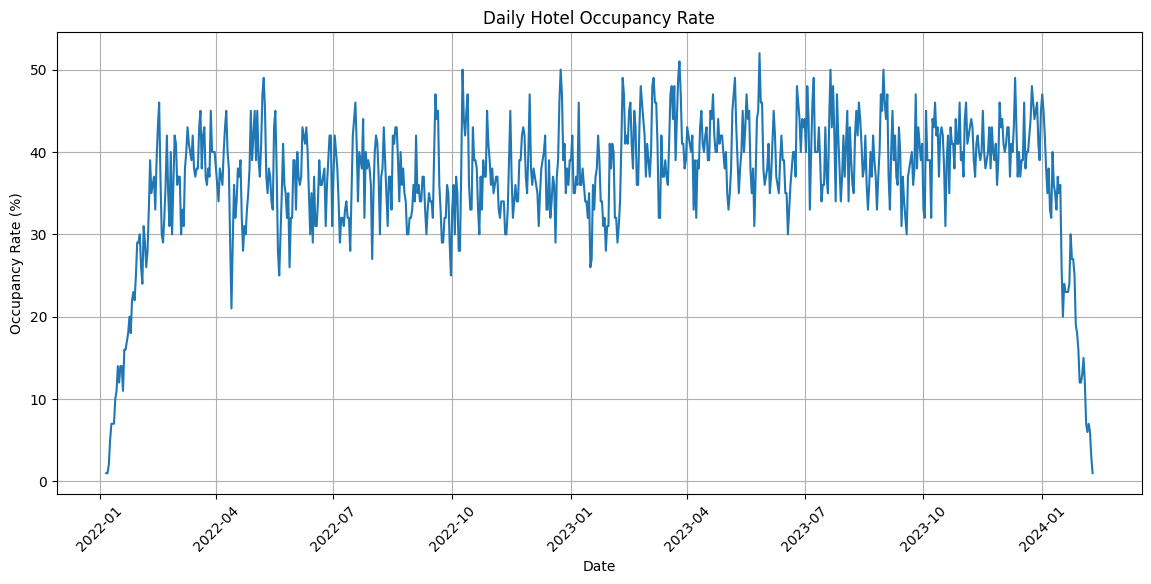

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    occupancy_df["Date"],
    occupancy_df["Occupancy Rate"]
)

plt.xlabel("Date")
plt.ylabel("Occupancy Rate (%)")
plt.title("Daily Hotel Occupancy Rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [38]:
occupancy_df["Day"] = occupancy_df["Date"].dt.day
occupancy_df["Month"] = occupancy_df["Date"].dt.month
occupancy_df["Year"] = occupancy_df["Date"].dt.year
occupancy_df["DayOfWeek"] = occupancy_df["Date"].dt.dayofweek

In [39]:
occupancy_df.head()

,Date,Occupied Rooms,Occupancy Rate,Day,Month,Year,DayOfWeek
0,2022-01-06,1,1.0,6,1,2022,3
1,2022-01-07,1,1.0,7,1,2022,4
2,2022-01-08,2,2.0,8,1,2022,5
3,2022-01-09,5,5.0,9,1,2022,6
4,2022-01-10,7,7.0,10,1,2022,0


In [40]:
X = occupancy_df[["Day", "Month", "Year", "DayOfWeek", "Occupied Rooms"]]

y = occupancy_df["Occupancy Rate"]

In [41]:
X.head()

,Day,Month,Year,DayOfWeek,Occupied Rooms
0,6,1,2022,3,1
1,7,1,2022,4,1
2,8,1,2022,5,2
3,9,1,2022,6,5
4,10,1,2022,0,7


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (612, 5)
X_test: (153, 5)
y_train: (612,)
y_test: (153,)


In [43]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [44]:
y_pred = dt_model.predict(X_test)

print(y_pred[:10])

[38.         33.51020408 17.75       45.325      36.         37.
 33.51020408 41.56923077 41.56923077 37.        ]


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.2705007644083275
MSE : 0.1979581242737852
RMSE: 0.4449248523894627
R²  : 0.9969775503092726


In [46]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [47]:
y_pred_rf = rf_model.predict(X_test)

print(y_pred_rf[:10])

[38.   33.   17.95 46.   36.   37.   34.   41.   42.   37.  ]


In [48]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 0.050588235294117705
MSE : 0.05884575163398699
RMSE: 0.2425814329951635
R²  : 0.9991015356178018


In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Occupied Rooms,0.998769
0,Day,0.000861
3,DayOfWeek,0.000296
2,Year,0.000051
1,Month,0.000023


In [50]:
occupancy_df["Lag_1"] = occupancy_df["Occupancy Rate"].shift(1)
occupancy_df["Lag_7"] = occupancy_df["Occupancy Rate"].shift(7)

occupancy_df = occupancy_df.dropna()

occupancy_df.head(10)

,Date,Occupied Rooms,Occupancy Rate,Day,Month,Year,DayOfWeek,Lag_1,Lag_7
7,2022-01-13,10,10.0,13,1,2022,3,7.0,1.0
8,2022-01-14,11,11.0,14,1,2022,4,10.0,1.0
9,2022-01-15,14,14.0,15,1,2022,5,11.0,2.0
10,2022-01-16,12,12.0,16,1,2022,6,14.0,5.0
11,2022-01-17,14,14.0,17,1,2022,0,12.0,7.0
12,2022-01-18,14,14.0,18,1,2022,1,14.0,7.0
13,2022-01-19,11,11.0,19,1,2022,2,14.0,7.0
14,2022-01-20,16,16.0,20,1,2022,3,11.0,10.0
15,2022-01-21,16,16.0,21,1,2022,4,16.0,11.0
16,2022-01-22,17,17.0,22,1,2022,5,16.0,14.0


In [51]:
X = occupancy_df[[
    "Day",
    "Month",
    "Year",
    "DayOfWeek",
    "Lag_1",
    "Lag_7"
]]

y = occupancy_df["Occupancy Rate"]


In [52]:
X.head()

,Day,Month,Year,DayOfWeek,Lag_1,Lag_7
7,13,1,2022,3,7.0,1.0
8,14,1,2022,4,10.0,1.0
9,15,1,2022,5,11.0,2.0
10,16,1,2022,6,14.0,5.0
11,17,1,2022,0,12.0,7.0


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (606, 6)
X_test: (152, 6)
y_train: (606,)
y_test: (152,)


In [54]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [55]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

MAE : 3.3859382786799923
MSE : 17.872642519140687
RMSE: 4.227604820597674
R²  : 0.7313669686568032


In [56]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [57]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 3.2402324559286013
MSE : 16.3903050079665
RMSE: 4.048494165485051
R²  : 0.7536470997943221


In [58]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Lag_1,0.738409
0,Day,0.074436
5,Lag_7,0.071933
1,Month,0.050592
3,DayOfWeek,0.041375
2,Year,0.023254


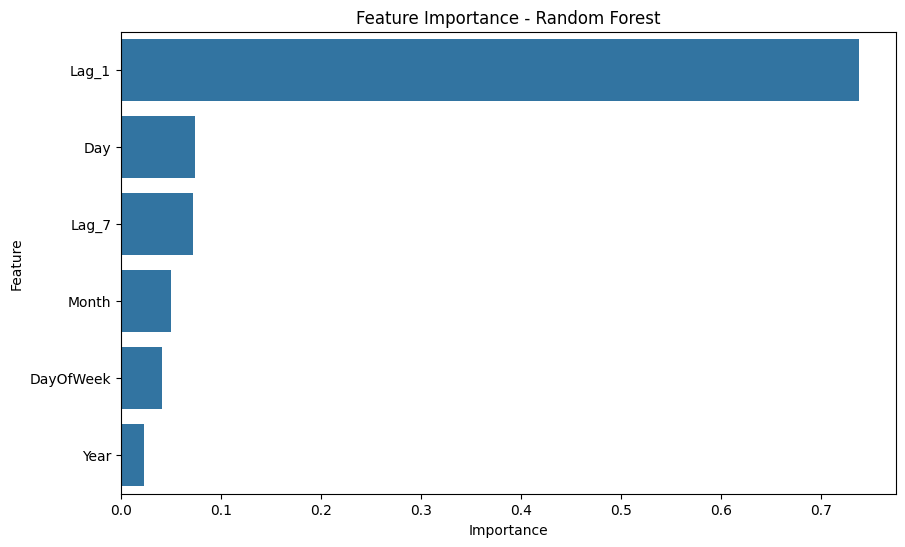

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

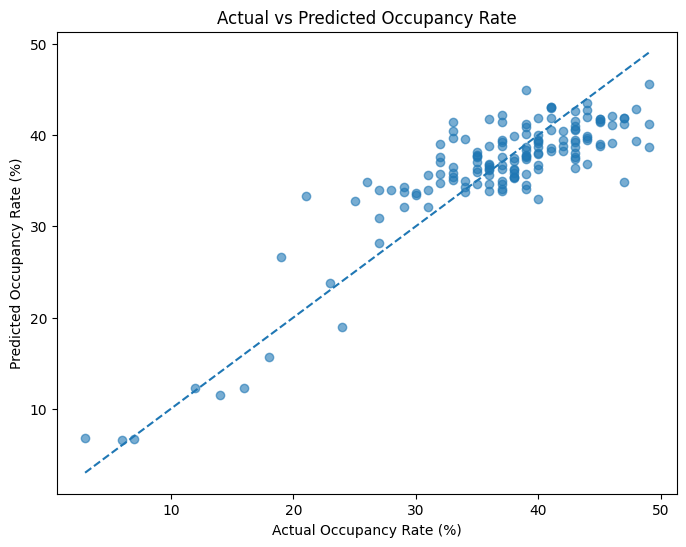

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.xlabel("Actual Occupancy Rate (%)")
plt.ylabel("Predicted Occupancy Rate (%)")
plt.title("Actual vs Predicted Occupancy Rate")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [61]:
split_index = int(len(occupancy_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (606, 6)
X_test: (152, 6)
y_train: (606,)
y_test: (152,)


In [62]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [63]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 4.167904596115221
MSE : 28.96081670317505
RMSE: 5.381525499630662
R²  : 0.7068528526032959


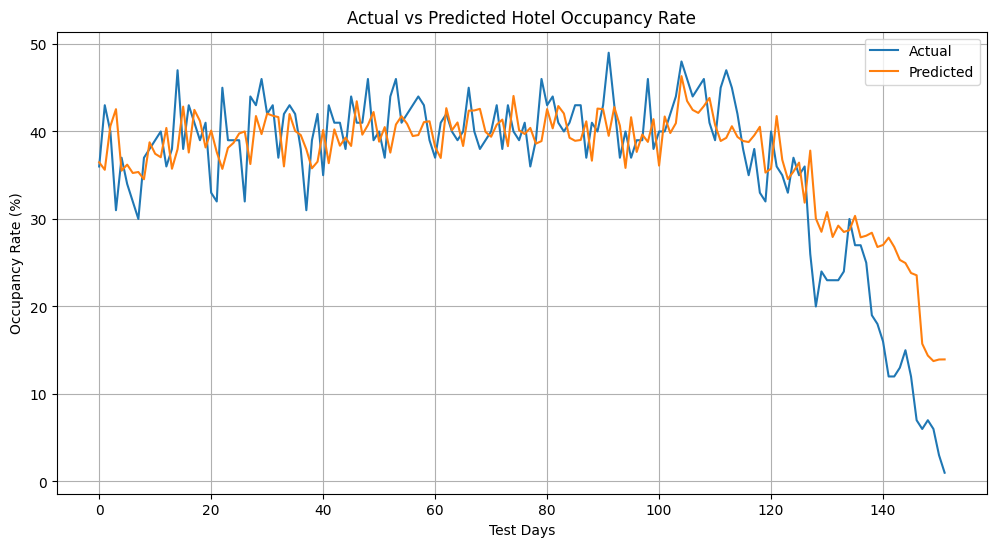

In [64]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Predicted")

plt.xlabel("Test Days")
plt.ylabel("Occupancy Rate (%)")
plt.title("Actual vs Predicted Hotel Occupancy Rate")
plt.legend()
plt.grid(True)

plt.show()

In [65]:
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae_rf, mse_rf, rmse_rf, r2_rf]
})

results

,Metric,Value
0,MAE,4.167905
1,MSE,28.960817
2,RMSE,5.381525
3,R²,0.706853


In [66]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Lag_1,0.469700
5,Lag_7,0.286676
0,Day,0.103745
1,Month,0.062839
3,DayOfWeek,0.057832
2,Year,0.019207


In [67]:
example = X_test.iloc[[0]]

prediction = rf_model.predict(example)[0]

print("Predicted Occupancy Rate:", round(prediction, 2), "%")

Predicted Occupancy Rate: 36.48 %


In [68]:
import joblib

joblib.dump(rf_model, "hotel_occupancy_random_forest.pkl")

['hotel_occupancy_random_forest.pkl']

In [69]:
new_data = pd.DataFrame({
    "Day": [15],
    "Month": [2],
    "Year": [2024],
    "DayOfWeek": [3],
    "Lag_1": [35],
    "Lag_7": [38]
})

prediction = rf_model.predict(new_data)[0]

print("Predicted Occupancy Rate:", round(prediction, 2), "%")

Predicted Occupancy Rate: 36.76 %
